# Stock NeurIPS2018 Part 3. Backtest
This series is a reproduction of paper *the process in the paper Practical Deep Reinforcement Learning Approach for Stock Trading*. 

This is the third and last part of the NeurIPS2018 series, introducing how to use use the agents we trained to do backtest, and compare with baselines such as Mean Variance Optimization and DJIA index.

Other demos can be found at the repo of [FinRL-Tutorials]((https://github.com/AI4Finance-Foundation/FinRL-Tutorials)).

# Part 1. Install Packages

In [171]:
## install finrl library
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to c:\users\ansl\appdata\local\temp\pip-req-build-kauvgibr
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit fee45af12ee0af490cd8e091514173b571dcd9ed
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to c:\users\ansl\appdata\local\temp\pip-install-wo53j9zc\elegantrl_5fdac1f2b0a74db9a75a892f26c48516
  Resolved https://github.com/AI4Finance-Foundation/ElegantRL.git to commit 95a1a6bbc92e62c8d2ac470b2315d961da343889
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Gett

  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git 'C:\Users\ANSL\AppData\Local\Temp\pip-req-build-kauvgibr'
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/ElegantRL.git 'C:\Users\ANSL\AppData\Local\Temp\pip-install-wo53j9zc\elegantrl_5fdac1f2b0a74db9a75a892f26c48516'


In [172]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
import gymnasium as gym
from gymnasium import spaces

from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.config import INDICATORS, TRAINED_MODEL_DIR
from finrl.meta.env_cryptocurrency_trading.env_multiple_crypto import CryptoEnv

%matplotlib inline

# Part 2. Backtesting

To backtest the agents, upload trade_data.csv in the same directory of this notebook. For Colab users, just upload trade_data.csv to the default directory.

In [173]:
# 암호화폐 데이터 로드 (Part 2에서 저장한 테스트 데이터)
data = np.load('crypto_test_data.npz', allow_pickle=True)

test_price = data['test_price']
test_tech = data['test_tech']
crypto_pairs = data['crypto_pairs']

print(f"테스트 데이터: {len(test_price)} 샘플")
print(f"코인 수: {test_price.shape[1]}")
print(f"코인 목록: {crypto_pairs}")

# CryptoEnv를 사용하므로 test 데이터를 trade로 사용
trade_price = test_price
trade_tech = test_tech

테스트 데이터: 1706 샘플
코인 수: 5
코인 목록: ['BTC/USDT' 'ETH/USDT' 'BNB/USDT' 'XRP/USDT' 'SOL/USDT']


Then, upload the trained agent to the same directory, and set the corresponding variable to True.

In [174]:
if_using_a2c = True
if_using_ddpg = True
if_using_ppo = True
if_using_td3 = True
if_using_sac = True

Load the agents

In [175]:
trained_a2c = A2C.load(TRAINED_MODEL_DIR + "/crypto_a2c") if if_using_a2c else None
# trained_ddpg = DDPG.load(TRAINED_MODEL_DIR + "/agent_ddpg") if if_using_ddpg else None
trained_ppo = PPO.load(TRAINED_MODEL_DIR + "/crypto_ppo") if if_using_ppo else None
# trained_td3 = TD3.load(TRAINED_MODEL_DIR + "/agent_td3") if if_using_td3 else None
# trained_sac = SAC.load(TRAINED_MODEL_DIR + "/agent_sac") if if_using_sac else None

### Trading (Out-of-sample Performance)

We update periodically in order to take full advantage of the data, e.g., retrain quarterly, monthly or weekly. We also tune the parameters along the way, in this notebook we use the in-sample data from 2009-01 to 2020-07 to tune the parameters once, so there is some alpha decay here as the length of trade date extends. 

Numerous hyperparameters – e.g. the learning rate, the total number of samples to train on – influence the learning process and are usually determined by testing some variations.

In [176]:
# 암호화폐 데이터의 경우
stock_dimension = trade_price.shape[1]  # 코인 수
state_space = 1 + trade_price.shape[1] + trade_tech.shape[1]  # cash + 보유량 + 기술지표
print(f"Crypto Dimension: {stock_dimension}, State Space: {state_space}")
print(f"코인 목록: {crypto_pairs}")

Crypto Dimension: 5, State Space: 41
코인 목록: ['BTC/USDT' 'ETH/USDT' 'BNB/USDT' 'XRP/USDT' 'SOL/USDT']


In [177]:
# CryptoEnv 설정
env_kwargs = {
    "lookback": 1,
    "initial_capital": 1_000_000,  # 초기 자본 100만 USDT
    "buy_cost_pct": 0.001,         # 매수 수수료 0.1%
    "sell_cost_pct": 0.001,        # 매도 수수료 0.1%
}

In [178]:
# CryptoEnv를 사용한 테스트 환경 생성
test_config = {
    "price_array": trade_price,
    "tech_array": trade_tech,
}

# Gymnasium 래퍼 클래스 정의 (DRLAgent 호환성을 위해 확장)
from stable_baselines3.common.vec_env import DummyVecEnv

class CryptoEnvGym(gym.Env):
    """CryptoEnv를 Gymnasium 인터페이스로 래핑하고 DRLAgent 호환성 추가"""
    
    def __init__(self, config, **kwargs):
        super().__init__()
        self.env = CryptoEnv(config, **kwargs)
        
        # Gymnasium spaces 정의
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, 
            shape=(self.env.state_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1, high=1, 
            shape=(self.env.action_dim,), dtype=np.float32
        )
        
        # 메모리 추적 (DRLAgent를 위해 필요)
        self.asset_memory = []
        self.actions_memory = []
        self.date_memory = []
        
        # 가짜 DataFrame 생성 (DRL_prediction이 df.index를 사용)
        # 실제로는 사용하지 않지만 호환성을 위해 필요
        # 각 날짜마다 각 코인에 대한 행을 생성
        num_periods = self.env.max_step + self.env.lookback
        dates = pd.date_range(start='2024-01-01', periods=num_periods, freq='5min')
        
        # 각 날짜마다 각 코인에 대한 행 생성
        date_list = []
        tic_list = []
        close_list = []
        
        for date_idx in range(num_periods):
            for crypto_idx in range(len(crypto_pairs)):
                date_list.append(dates[date_idx])
                tic_list.append(crypto_pairs[crypto_idx])
                if date_idx < trade_price.shape[0]:
                    close_list.append(trade_price[date_idx][crypto_idx])
                else:
                    close_list.append(trade_price[-1][crypto_idx])  # 마지막 값 사용
        
        self.df = pd.DataFrame({
            'date': date_list,
            'tic': tic_list,
            'close': close_list
        })
        self.df = self.df.set_index('date')
    
    def reset(self, seed=None, options=None):
        # reset 전에 메모리 백업 (done=True일 때 자동 reset되기 전에 저장하기 위해)
        # 메모리가 있으면 항상 백업 (최신 상태 유지)
        if len(self.asset_memory) > 0 or len(self.actions_memory) > 0:
            self._backup_asset_memory = self.asset_memory.copy()
            self._backup_actions_memory = self.actions_memory.copy()
            self._backup_date_memory = self.date_memory.copy()
        
        state = self.env.reset(seed=seed, options=options)
        # 메모리 초기화
        self.asset_memory = [self.env.initial_total_asset]
        self.actions_memory = []
        self.date_memory = []
        # 초기 날짜 추가 (reset 시점)
        # df.index는 각 코인마다 중복되므로 고유한 날짜만 사용
        unique_dates = self.df.index.unique()
        if len(unique_dates) > 0:
            # lookback 시점의 날짜 추가
            initial_idx = self.env.time - self.env.lookback + 1
            if 0 <= initial_idx < len(unique_dates):
                self.date_memory.append(unique_dates[initial_idx])
            else:
                self.date_memory.append(unique_dates[0])
        return state, {}
    
    def step(self, action):
        # 액션을 numpy 배열로 변환하고 복사 (정규화 전 원본 액션 저장)
        if isinstance(action, np.ndarray):
            action_to_store = action.copy()
        elif hasattr(action, 'copy'):
            action_to_store = action.copy()
        else:
            action_to_store = np.array(action)
        
        # done이 True가 될 수 있는지 미리 확인
        will_be_done = (self.env.time + 1) == self.env.max_step
        
        state, reward, done, info = self.env.step(action)
        
        # 메모리 저장 (step 후에 저장하므로 asset은 업데이트된 값)
        self.asset_memory.append(self.env.total_asset)
        
        # 액션 저장 (정규화 전 원본 액션)
        # action_to_store가 1D 배열이면 그대로 저장, 아니면 첫 번째 요소 사용
        if action_to_store.ndim > 1:
            action_to_store = action_to_store[0] if len(action_to_store) > 0 else action_to_store.flatten()
        self.actions_memory.append(action_to_store)
        
        # 날짜 추가 (현재 time 인덱스 사용)
        # df.index는 각 코인마다 중복되므로, 고유한 날짜만 사용
        unique_dates = self.df.index.unique()
        # time은 lookback부터 시작하므로, time - lookback + 1이 실제 데이터 인덱스
        data_idx = self.env.time - self.env.lookback + 1
        if 0 <= data_idx < len(unique_dates):
            self.date_memory.append(unique_dates[data_idx])
        elif len(unique_dates) > 0:
            # 범위를 벗어나면 마지막 날짜 사용
            self.date_memory.append(unique_dates[-1])
        
        # done이 True이면 reset()이 호출되기 전에 메모리 백업
        if done:
            self._backup_asset_memory = self.asset_memory.copy()
            self._backup_actions_memory = self.actions_memory.copy()
            self._backup_date_memory = self.date_memory.copy()
        
        return state, reward, done, False, info or {}
    
    def get_sb_env(self):
        """DRLAgent를 위한 메서드"""
        # 현재 인스턴스를 직접 참조하도록 클로저 사용
        # DummyVecEnv는 환경을 래핑하므로 현재 인스턴스의 메서드가 호출됨
        env_instance = self
        e = DummyVecEnv([lambda: env_instance])
        obs = e.reset()
        return e, obs
    
    def save_asset_memory(self):
        """DRLAgent를 위한 메서드"""
        # reset()으로 인해 메모리가 초기화되었을 수 있으므로 백업된 메모리 사용
        # 백업이 있으면 백업 사용, 없으면 현재 메모리 사용
        if hasattr(self, '_backup_asset_memory') and len(self._backup_asset_memory) > 0:
            asset_memory_to_use = self._backup_asset_memory
            date_memory_to_use = self._backup_date_memory
        else:
            asset_memory_to_use = self.asset_memory
            date_memory_to_use = self.date_memory
        
        # asset_memory와 date_memory의 길이를 맞춤
        min_len = min(len(asset_memory_to_use), len(date_memory_to_use))
        date_list = date_memory_to_use[:min_len] if len(date_memory_to_use) >= min_len else date_memory_to_use + [date_memory_to_use[-1]] * (min_len - len(date_memory_to_use)) if date_memory_to_use else []
        asset_list = asset_memory_to_use[:min_len]
        
        # 길이가 맞지 않으면 조정
        if len(date_list) != len(asset_list):
            min_len = min(len(date_list), len(asset_list))
            date_list = date_list[:min_len]
            asset_list = asset_list[:min_len]
        
        df_account_value = pd.DataFrame(
            {"date": date_list, "account_value": asset_list}
        )
        return df_account_value
    
    def save_action_memory(self):
        """DRLAgent를 위한 메서드"""
        # reset()으로 인해 메모리가 초기화되었을 수 있으므로 백업된 메모리 사용
        # 백업이 있으면 백업 사용, 없으면 현재 메모리 사용
        if hasattr(self, '_backup_actions_memory') and len(self._backup_actions_memory) > 0:
            actions_memory_to_use = self._backup_actions_memory
            date_memory_to_use = self._backup_date_memory
        else:
            actions_memory_to_use = self.actions_memory
            date_memory_to_use = self.date_memory
        
        action_len = len(actions_memory_to_use)
        date_len = len(date_memory_to_use)
        
        if action_len == 0:
            # 액션이 없으면 빈 DataFrame 반환
            if len(crypto_pairs) > 1:
                return pd.DataFrame(columns=crypto_pairs)
            else:
                return pd.DataFrame(columns=["date", "actions"])
        
        # date_memory는 reset 시점부터 시작
        # step()에서 액션을 저장한 후 날짜를 추가하므로:
        # - date_memory[0] = reset 시점 날짜
        # - date_memory[1:] = 각 step 후 날짜들 (actions_memory와 매칭)
        # 따라서 date_memory[1:]와 actions_memory를 매칭해야 함
        
        # 날짜와 액션 매칭 로직 개선
        # date_memory는 reset 시점부터 시작하므로:
        # - date_memory[0] = reset 시점 날짜
        # - date_memory[1:] = 각 step 후 날짜들 (actions_memory와 매칭되어야 함)
        
        if date_len > 1:
            # reset 후 첫 step부터의 날짜 사용
            # date_memory[1:]의 길이는 action_len과 같아야 함
            if action_len > 0:
                # 액션이 있으면 date_memory[1:]와 매칭 시도
                expected_date_len = action_len + 1  # reset 날짜 포함
                if date_len >= expected_date_len:
                    # 날짜가 충분하면 date_memory[1:action_len+1] 사용
                    date_list = date_memory_to_use[1:action_len + 1]
                elif date_len > 1:
                    # 날짜가 부족하면 있는 만큼만 사용
                    date_list = date_memory_to_use[1:]
                else:
                    date_list = []
            else:
                date_list = []
        else:
            # 날짜가 1개만 있으면 (reset만 호출된 경우)
            date_list = []
        
        # 날짜와 액션 길이 확인 및 조정
        if action_len == 0:
            # 액션이 없으면 빈 DataFrame 반환 (이미 위에서 처리됨)
            date_list = []
            action_list = []
        elif len(date_list) == action_len:
            # 길이가 정확히 맞으면 그대로 사용
            action_list = actions_memory_to_use
        elif len(date_list) > 0 and len(date_list) < action_len:
            # 날짜가 적으면 날짜만큼만 액션 사용
            action_list = actions_memory_to_use[:len(date_list)]
            date_list = date_list[:len(action_list)]
        elif len(date_list) > action_len:
            # 날짜가 많으면 액션만큼만 날짜 사용
            date_list = date_list[:action_len]
            action_list = actions_memory_to_use
        else:
            # 날짜가 없거나 길이가 안 맞으면 액션만 사용하고 날짜 생성
            action_list = actions_memory_to_use
            if len(self.df.index.unique()) > 0:
                unique_dates = self.df.index.unique()
                if action_len <= len(unique_dates):
                    # 액션 개수만큼 날짜 생성 (reset 후 첫 step부터)
                    date_list = list(unique_dates[:action_len])
                else:
                    # 액션이 더 많으면 날짜를 반복
                    date_list = list(unique_dates) + [unique_dates[-1]] * (action_len - len(unique_dates))
            else:
                date_list = []
        
        if len(action_list) == 0:
            if len(crypto_pairs) > 1:
                return pd.DataFrame(columns=crypto_pairs)
            else:
                return pd.DataFrame(columns=["date", "actions"])
        
        # 액션 리스트를 DataFrame으로 변환
        try:
            if len(crypto_pairs) > 1:
                # 2D 배열로 변환
                action_array = np.array(action_list)
                
                # 차원 확인 및 조정
                if action_array.ndim == 1:
                    # 1D 배열이면 각 액션이 스칼라인 경우 -> reshape 필요
                    # 하지만 우리는 각 액션이 코인 수만큼의 배열이어야 함
                    if len(action_array) == len(crypto_pairs):
                        # 전체가 하나의 액션인 경우
                        action_array = action_array.reshape(1, -1)
                    else:
                        # 잘못된 형식
                        print(f"경고: 액션 배열 형식이 예상과 다릅니다. shape: {action_array.shape}")
                        return pd.DataFrame(columns=crypto_pairs)
                
                # 행과 열 확인
                if action_array.shape[0] != len(action_list):
                    print(f"경고: 액션 배열 행 수가 맞지 않습니다. {action_array.shape[0]} != {len(action_list)}")
                
                # 컬럼 수 확인 및 조정
                if action_array.shape[1] != len(crypto_pairs):
                    if action_array.shape[1] < len(crypto_pairs):
                        # 컬럼이 부족하면 0으로 패딩
                        padding = np.zeros((action_array.shape[0], len(crypto_pairs) - action_array.shape[1]))
                        action_array = np.hstack([action_array, padding])
                    else:
                        # 컬럼이 많으면 잘라냄
                        action_array = action_array[:, :len(crypto_pairs)]
                
                df_actions = pd.DataFrame(action_array, columns=crypto_pairs)
                
                # 인덱스 설정
                if len(date_list) == len(df_actions):
                    df_actions.index = date_list
                elif len(date_list) > 0:
                    # 날짜가 더 많으면 앞부분만 사용
                    df_actions.index = date_list[:len(df_actions)]
                else:
                    # 날짜가 없으면 숫자 인덱스 사용
                    df_actions.index = range(len(df_actions))
            else:
                # 단일 코인인 경우
                if len(date_list) == len(action_list):
                    df_actions = pd.DataFrame({"date": date_list, "actions": action_list})
                else:
                    df_actions = pd.DataFrame({"actions": action_list})
                    if len(date_list) > 0:
                        df_actions["date"] = date_list[:len(action_list)]
        except Exception as e:
            print(f"액션 변환 오류: {e}")
            print(f"action_list 길이: {len(action_list)}")
            if len(action_list) > 0:
                print(f"첫 번째 액션 타입: {type(action_list[0])}")
                print(f"첫 번째 액션 shape: {action_list[0].shape if hasattr(action_list[0], 'shape') else 'N/A'}")
                print(f"첫 번째 액션: {action_list[0]}")
            # 오류 발생 시 빈 DataFrame 반환
            if len(crypto_pairs) > 1:
                return pd.DataFrame(columns=crypto_pairs)
            else:
                return pd.DataFrame(columns=["date", "actions"])
        
        return df_actions

# Gym 환경 생성
e_trade_gym = CryptoEnvGym(config=test_config, **env_kwargs)
print(f"테스트 환경 생성 완료!")
print(f"State Dim: {e_trade_gym.env.state_dim}")
print(f"Action Dim: {e_trade_gym.env.action_dim}")
print(f"Max Steps: {e_trade_gym.env.max_step}")

테스트 환경 생성 완료!
State Dim: 41
Action Dim: 5
Max Steps: 1704


In [179]:
# 디버깅: step()이 제대로 호출되는지 확인
print("환경 테스트:")
test_env, test_obs = e_trade_gym.get_sb_env()
print(f"초기 자산: {e_trade_gym.env.initial_total_asset}")
print(f"초기 메모리 길이 - asset: {len(e_trade_gym.asset_memory)}, actions: {len(e_trade_gym.actions_memory)}, dates: {len(e_trade_gym.date_memory)}")

# 몇 스텝 실행
for i in range(5):
    action = test_env.action_space.sample()
    test_obs, rewards, dones, info = test_env.step([action])
    print(f"Step {i+1}: asset_memory={len(e_trade_gym.asset_memory)}, actions_memory={len(e_trade_gym.actions_memory)}, dates={len(e_trade_gym.date_memory)}")
    if dones[0]:
        break

print(f"\n최종 메모리 길이 - asset: {len(e_trade_gym.asset_memory)}, actions: {len(e_trade_gym.actions_memory)}, dates: {len(e_trade_gym.date_memory)}")
if len(e_trade_gym.actions_memory) > 0:
    print(f"첫 번째 액션: {e_trade_gym.actions_memory[0]}")
    print(f"액션 타입: {type(e_trade_gym.actions_memory[0])}")

환경 테스트:
초기 자산: 1000000
초기 메모리 길이 - asset: 1, actions: 0, dates: 1
Step 1: asset_memory=2, actions_memory=1, dates=2
Step 2: asset_memory=3, actions_memory=2, dates=3
Step 3: asset_memory=4, actions_memory=3, dates=4
Step 4: asset_memory=5, actions_memory=4, dates=5
Step 5: asset_memory=6, actions_memory=5, dates=6

최종 메모리 길이 - asset: 6, actions: 5, dates: 6
첫 번째 액션: [-0.309  0.981  0.972  0.53   0.235]
액션 타입: <class 'numpy.ndarray'>


In [180]:
# DRL_prediction 후 환경 메모리 확인
print("="*60)
print("DRL_prediction 후 환경 메모리 확인")
print("="*60)

# 백테스트 전 환경 상태 확인
print(f"\n백테스트 전 e_trade_gym 메모리:")
print(f"  asset_memory 길이: {len(e_trade_gym.asset_memory)}")
print(f"  actions_memory 길이: {len(e_trade_gym.actions_memory)}")
print(f"  date_memory 길이: {len(e_trade_gym.date_memory)}")

# get_sb_env()로 생성된 환경 확인
test_env, test_obs = e_trade_gym.get_sb_env()
print(f"\nget_sb_env() 후:")
print(f"  test_env 타입: {type(test_env)}")
print(f"  test_env.envs[0] 타입: {type(test_env.envs[0])}")
print(f"  test_env.envs[0] is e_trade_gym: {test_env.envs[0] is e_trade_gym}")

# 내부 환경 확인
inner_env = test_env.envs[0]
print(f"\n내부 환경 메모리:")
print(f"  asset_memory 길이: {len(inner_env.asset_memory)}")
print(f"  actions_memory 길이: {len(inner_env.actions_memory)}")
print(f"  date_memory 길이: {len(inner_env.date_memory)}")

# reset 후 확인
test_env.reset()
print(f"\nreset() 후 내부 환경 메모리:")
print(f"  asset_memory 길이: {len(inner_env.asset_memory)}")
print(f"  actions_memory 길이: {len(inner_env.actions_memory)}")
print(f"  date_memory 길이: {len(inner_env.date_memory)}")

# 몇 스텝 실행
for i in range(3):
    action = test_env.action_space.sample()
    test_obs, rewards, dones, info = test_env.step([action])
    print(f"\nStep {i+1} 후 내부 환경 메모리:")
    print(f"  asset_memory 길이: {len(inner_env.asset_memory)}")
    print(f"  actions_memory 길이: {len(inner_env.actions_memory)}")
    print(f"  date_memory 길이: {len(inner_env.date_memory)}")
    if dones[0]:
        break

# save_action_memory 테스트
print(f"\nsave_action_memory() 테스트:")
actions_df = inner_env.save_action_memory()
print(f"  반환된 DataFrame shape: {actions_df.shape}")
print(f"  반환된 DataFrame:")
print(actions_df.head() if len(actions_df) > 0 else "  (비어있음)")

DRL_prediction 후 환경 메모리 확인

백테스트 전 e_trade_gym 메모리:
  asset_memory 길이: 6
  actions_memory 길이: 5
  date_memory 길이: 6

get_sb_env() 후:
  test_env 타입: <class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>
  test_env.envs[0] 타입: <class '__main__.CryptoEnvGym'>
  test_env.envs[0] is e_trade_gym: True

내부 환경 메모리:
  asset_memory 길이: 1
  actions_memory 길이: 0
  date_memory 길이: 1

reset() 후 내부 환경 메모리:
  asset_memory 길이: 1
  actions_memory 길이: 0
  date_memory 길이: 1

Step 1 후 내부 환경 메모리:
  asset_memory 길이: 2
  actions_memory 길이: 1
  date_memory 길이: 2

Step 2 후 내부 환경 메모리:
  asset_memory 길이: 3
  actions_memory 길이: 2
  date_memory 길이: 3

Step 3 후 내부 환경 메모리:
  asset_memory 길이: 4
  actions_memory 길이: 3
  date_memory 길이: 4

save_action_memory() 테스트:
  반환된 DataFrame shape: (3, 5)
  반환된 DataFrame:
                     BTC/USDT  ETH/USDT  BNB/USDT  XRP/USDT  SOL/USDT
2024-01-01 00:05:00  0.859743  0.314666 -0.146800  0.270583 -0.711007
2024-01-01 00:10:00  0.480577  0.272450 -0.462224 -0.5584

In [181]:
# 개선된 DRL_prediction 함수 (done=True 전에 메모리 저장)
from stable_baselines3.common.vec_env import DummyVecEnv

def improved_DRL_prediction(model, environment, deterministic=True):
    """CryptoEnvGym을 위한 개선된 예측 함수 - done=True 전에 메모리 저장"""
    test_env, test_obs = environment.get_sb_env()
    
    # 내부 환경 인스턴스 가져오기
    inner_env = test_env.envs[0]
    
    account_memory = None
    actions_memory = None
    
    test_env.reset()
    max_steps = len(environment.df.index.unique()) - 1
    total_steps = len(environment.df.index.unique())
    
    for i in range(total_steps):
        action, _states = model.predict(test_obs, deterministic=deterministic)
        test_obs, rewards, dones, info = test_env.step(action)
        
        # done=True가 되면 DummyVecEnv가 자동으로 reset()을 호출하므로
        # 그 전에 메모리를 저장해야 함
        # step() 메서드에서 done=True일 때 자동으로 백업하도록 수정했으므로
        # 여기서는 백업된 메모리를 사용하면 됨
        if dones[0]:
            print("hit end!")
            # done이 True이면 step()에서 이미 백업했으므로 백업된 메모리 사용
            account_memory = test_env.env_method(method_name="save_asset_memory")
            actions_memory = test_env.env_method(method_name="save_action_memory")
            break
        elif i == max_steps:
            # 마지막 스텝에 도달했지만 done이 False일 수도 있음
            # 이 경우에도 메모리 저장
            account_memory = test_env.env_method(method_name="save_asset_memory")
            actions_memory = test_env.env_method(method_name="save_action_memory")
    
    # 메모리가 저장되지 않았으면 강제로 저장 (루프가 끝났을 때)
    if account_memory is None or actions_memory is None:
        account_memory = test_env.env_method(method_name="save_asset_memory")
        actions_memory = test_env.env_method(method_name="save_action_memory")
    
    return account_memory[0] if account_memory else None, actions_memory[0] if actions_memory else None

In [182]:
# PPO 결과 확인
print("="*60)
print("PPO 백테스트 결과 확인")
print("="*60)

if 'df_account_value_ppo' in globals() and df_account_value_ppo is not None:
    print(f"\nPPO 계좌 가치 데이터:")
    print(f"  Shape: {df_account_value_ppo.shape}")
    print(f"  샘플 (처음 5개):")
    print(df_account_value_ppo.head())
    print(f"  샘플 (마지막 5개):")
    print(df_account_value_ppo.tail())
    print(f"\n  초기 자산: {df_account_value_ppo.iloc[0]['account_value']:,.0f}")
    print(f"  최종 자산: {df_account_value_ppo.iloc[-1]['account_value']:,.0f}")
    print(f"  총 수익률: {(df_account_value_ppo.iloc[-1]['account_value'] / df_account_value_ppo.iloc[0]['account_value'] - 1) * 100:.2f}%")
else:
    print("PPO 계좌 가치 데이터가 없습니다.")

if 'df_actions_ppo' in globals() and df_actions_ppo is not None:
    print(f"\nPPO 액션 데이터:")
    print(f"  Shape: {df_actions_ppo.shape}")
    print(f"  샘플 (처음 5개):")
    print(df_actions_ppo.head())
    print(f"  샘플 (마지막 5개):")
    print(df_actions_ppo.tail())
    print(f"\n  총 액션 수: {len(df_actions_ppo)}")
else:
    print("PPO 액션 데이터가 없습니다.")

PPO 백테스트 결과 확인

PPO 계좌 가치 데이터:
  Shape: (1705, 2)
  샘플 (처음 5개):
                 date   account_value
0 2024-01-01 00:00:00  1000000.000000
1 2024-01-01 00:05:00   999999.565118
2 2024-01-01 00:10:00   999998.830899
3 2024-01-01 00:15:00   999998.701787
4 2024-01-01 00:20:00   999999.866641
  샘플 (마지막 5개):
                    date  account_value
1700 2024-01-06 21:40:00  987192.788138
1701 2024-01-06 21:45:00  987366.631922
1702 2024-01-06 21:50:00  987234.171353
1703 2024-01-06 21:55:00  987379.953222
1704 2024-01-06 22:00:00  987378.449538

  초기 자산: 1,000,000
  최종 자산: 987,378
  총 수익률: -1.26%

PPO 액션 데이터:
  Shape: (1704, 5)
  샘플 (처음 5개):
                     BTC/USDT  ETH/USDT  BNB/USDT  XRP/USDT  SOL/USDT
2024-01-01 00:05:00 -0.151124  0.119501 -0.165460 -0.034229  0.026275
2024-01-01 00:10:00 -0.150715  0.119356 -0.166368 -0.033628  0.027242
2024-01-01 00:15:00 -0.150280  0.119207 -0.167312 -0.032982  0.028240
2024-01-01 00:20:00 -0.149826  0.119050 -0.168285 -0.032308  0.029274
2024

In [183]:
# A2C와 PPO 액션 확인
print("="*60)
print("A2C 액션 확인")
print("="*60)
if 'df_actions_a2c' in globals() and df_actions_a2c is not None:
    print(f"A2C 액션 데이터 shape: {df_actions_a2c.shape}")
    print(f"A2C 액션 샘플 (처음 5개):")
    print(df_actions_a2c.head())
    print(f"\nA2C 액션 통계:")
    print(df_actions_a2c.describe())
    print(f"\nA2C 액션 합계 (각 코인별):")
    if len(df_actions_a2c.columns) > 1:
        print(df_actions_a2c.sum())
    else:
        print("액션 데이터가 없거나 형식이 다릅니다.")
else:
    print("A2C 액션 데이터가 없습니다.")

print("\n" + "="*60)
print("PPO 액션 확인")
print("="*60)
if 'df_actions_ppo' in globals() and df_actions_ppo is not None:
    print(f"PPO 액션 데이터 shape: {df_actions_ppo.shape}")
    print(f"PPO 액션 샘플 (처음 5개):")
    print(df_actions_ppo.head())
    print(f"\nPPO 액션 통계:")
    print(df_actions_ppo.describe())
    print(f"\nPPO 액션 합계 (각 코인별):")
    if len(df_actions_ppo.columns) > 1:
        print(df_actions_ppo.sum())
    else:
        print("액션 데이터가 없거나 형식이 다릅니다.")
else:
    print("PPO 액션 데이터가 없습니다.")

# 계좌 가치 변화 확인
print("\n" + "="*60)
print("A2C 계좌 가치 확인")
print("="*60)
if 'df_account_value_a2c' in globals() and df_account_value_a2c is not None:
    print(f"A2C 계좌 가치 데이터 shape: {df_account_value_a2c.shape}")
    print(f"A2C 계좌 가치 샘플:")
    print(df_account_value_a2c.head(10))
    print(f"\nA2C 계좌 가치 통계:")
    print(df_account_value_a2c.describe())
else:
    print("A2C 계좌 가치 데이터가 없습니다.")

print("\n" + "="*60)
print("PPO 계좌 가치 확인")
print("="*60)
if 'df_account_value_ppo' in globals() and df_account_value_ppo is not None:
    print(f"PPO 계좌 가치 데이터 shape: {df_account_value_ppo.shape}")
    print(f"PPO 계좌 가치 샘플:")
    print(df_account_value_ppo.head(10))
    print(f"\nPPO 계좌 가치 통계:")
    print(df_account_value_ppo.describe())
else:
    print("PPO 계좌 가치 데이터가 없습니다.")

A2C 액션 확인
A2C 액션 데이터 shape: (1704, 5)
A2C 액션 샘플 (처음 5개):
                     BTC/USDT  ETH/USDT  BNB/USDT  XRP/USDT  SOL/USDT
2024-01-01 00:05:00  0.187943 -0.624221  0.625064 -0.508242  0.679648
2024-01-01 00:10:00  0.566510 -0.966651  1.000000 -0.461086  1.000000
2024-01-01 00:15:00  1.000000 -1.000000  1.000000 -0.368102  1.000000
2024-01-01 00:20:00  1.000000 -1.000000  1.000000 -0.264512  1.000000
2024-01-01 00:25:00  1.000000 -1.000000  1.000000 -0.165612  1.000000

A2C 액션 통계:
          BTC/USDT     ETH/USDT     BNB/USDT     XRP/USDT     SOL/USDT
count  1704.000000  1704.000000  1704.000000  1704.000000  1704.000000
mean      0.999269    -0.999760     0.999780     0.165655     0.999812
std       0.022294     0.009139     0.009083     0.031093     0.007761
min       0.187943    -1.000000     0.625064    -0.508242     0.679648
25%       1.000000    -1.000000     1.000000     0.165898     1.000000
50%       1.000000    -1.000000     1.000000     0.166421     1.000000
75%       1.00

In [184]:
# 개선된 DRL_prediction 함수 사용 (done=True 전에 메모리 저장)
df_account_value_a2c, df_actions_a2c = improved_DRL_prediction(
    model=trained_a2c, 
    environment=e_trade_gym) if if_using_a2c else (None, None)

hit end!


In [185]:
# df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
#     model=trained_ddpg, 
#     environment = e_trade_gym) if if_using_ddpg else (None, None)

In [186]:
# 개선된 DRL_prediction 함수 사용 (done=True 전에 메모리 저장)
df_account_value_ppo, df_actions_ppo = improved_DRL_prediction(
    model=trained_ppo, 
    environment=e_trade_gym) if if_using_ppo else (None, None)

hit end!


In [187]:
# df_account_value_td3, df_actions_td3 = DRLAgent.DRL_prediction(
#     model=trained_td3, 
#     environment = e_trade_gym) if if_using_td3 else (None, None)

In [188]:
df_account_value_sac, df_actions_sac = DRLAgent.DRL_prediction(
    model=trained_sac, 
    environment = e_trade_gym) if if_using_sac else (None, None)

NameError: name 'trained_sac' is not defined

# Part 3: Mean Variance Optimization

Mean Variance optimization is a very classic strategy in portfolio management. Here, we go through the whole process to do the mean variance optimization and add it as a baseline to compare.

First, process dataframe to the form for MVO weight calculation.

In [ ]:
def process_df_for_mvo(df):
  return df.pivot(index="date", columns="tic", values="close")

### Helper functions for mean returns and variance-covariance matrix

In [ ]:
# Codes in this section partially refer to Dr G A Vijayalakshmi Pai
# https://www.kaggle.com/code/vijipai/lesson-5-mean-variance-optimization-of-portfolios/notebook

def StockReturnsComputing(StockPrice, Rows, Columns): 
  import numpy as np 
  StockReturn = np.zeros([Rows-1, Columns]) 
  for j in range(Columns):        # j: Assets 
    for i in range(Rows-1):     # i: Daily Prices 
      StockReturn[i,j]=((StockPrice[i+1, j]-StockPrice[i,j])/StockPrice[i,j])* 100 
      
  return StockReturn

### Calculate the weights for mean-variance

In [ ]:
# 암호화폐 데이터를 MVO용 DataFrame으로 변환
# train 데이터는 학습 데이터가 필요하지만, 여기서는 테스트 데이터만 사용
# MVO 비교를 위해 테스트 데이터를 사용

# 날짜 생성 (5분봉)
num_periods = trade_price.shape[0]
dates = pd.date_range(start='2024-01-01', periods=num_periods, freq='5min')

# MVO용 DataFrame 생성 (date, tic, close 형식)
mvo_data_list = []
for date_idx in range(num_periods):
    for crypto_idx in range(len(crypto_pairs)):
        mvo_data_list.append({
            'date': dates[date_idx],
            'tic': crypto_pairs[crypto_idx],
            'close': trade_price[date_idx][crypto_idx]
        })

trade_df = pd.DataFrame(mvo_data_list)

# MVO용 데이터 변환
TradeData = process_df_for_mvo(trade_df)
StockData = TradeData  # 학습 데이터가 없으므로 테스트 데이터 사용

print(f"TradeData shape: {TradeData.shape}")
print(f"TradeData columns: {TradeData.columns.tolist()}")
TradeData.head()

TradeData shape: (1706, 5)
TradeData columns: [np.str_('BNB/USDT'), np.str_('BTC/USDT'), np.str_('ETH/USDT'), np.str_('SOL/USDT'), np.str_('XRP/USDT')]


tic,BNB/USDT,BTC/USDT,ETH/USDT,SOL/USDT,XRP/USDT
date,,,,,
2024-01-01 00:00:00,945.37,94955.79,3324.99,141.72,2.0501
2024-01-01 00:05:00,946.03,95024.00,3327.22,141.87,2.0495
2024-01-01 00:10:00,945.68,94990.00,3324.83,141.82,2.0480
2024-01-01 00:15:00,945.65,95009.31,3326.05,141.85,2.0490
2024-01-01 00:20:00,946.31,95048.00,3330.07,142.05,2.0509


In [ ]:
#compute asset returns
arStockPrices = np.asarray(StockData)
[Rows, Cols]=arStockPrices.shape
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

#compute mean returns and variance covariance matrix of returns
meanReturns = np.mean(arReturns, axis = 0)
covReturns = np.cov(arReturns, rowvar=False)
 
#set precision for printing results
np.set_printoptions(precision=3, suppress = True)

#display mean returns and variance-covariance matrix of returns
print('Mean returns of assets in k-portfolio 1\n', meanReturns)
print('Variance-Covariance matrix of returns\n', covReturns)

Mean returns of assets in k-portfolio 1
 [-0.003 -0.003 -0.007 -0.006 -0.004]
Variance-Covariance matrix of returns
 [[0.017 0.015 0.021 0.02  0.02 ]
 [0.015 0.018 0.023 0.021 0.021]
 [0.021 0.023 0.036 0.03  0.029]
 [0.02  0.021 0.03  0.035 0.031]
 [0.02  0.021 0.029 0.031 0.039]]


### Use PyPortfolioOpt

In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier

# 암호화폐의 경우 무위험 이자율을 0 또는 매우 낮게 설정
# (암호화폐는 전통적인 무위험 자산이 없으므로)
risk_free_rate = 0.0  # 또는 연 0%로 설정

ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))

# max_sharpe가 실패할 경우를 대비해 try-except 사용
try:
    raw_weights_mean = ef_mean.max_sharpe(risk_free_rate=risk_free_rate)
    cleaned_weights_mean = ef_mean.clean_weights()
    mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(len(cleaned_weights_mean))])
    print("Sharpe ratio 최대화 성공")
except ValueError as e:
    print(f"Sharpe ratio 최대화 실패: {e}")
    print("대신 최소 변동성 포트폴리오 사용")
    # 최소 변동성 포트폴리오 사용
    raw_weights_mean = ef_mean.min_volatility()
    cleaned_weights_mean = ef_mean.clean_weights()
    mvo_weights = np.array([1000000 * cleaned_weights_mean[i] for i in range(len(cleaned_weights_mean))])

mvo_weights

Sharpe ratio 최대화 실패: at least one of the assets must have an expected return exceeding the risk-free rate
대신 최소 변동성 포트폴리오 사용


array([500000., 500000.,      0.,      0.,      0.])

In [ ]:
LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])
Initial_Portfolio = np.multiply(mvo_weights, LastPrice)
Initial_Portfolio

array([560.557,   5.584,   0.   ,   0.   ,   0.   ])

In [ ]:
Portfolio_Assets = TradeData @ Initial_Portfolio
MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])
MVO_result

,Mean Var
date,
2024-01-01 00:00:00,1.060189e+06
2024-01-01 00:05:00,1.060940e+06
2024-01-01 00:10:00,1.060554e+06
2024-01-01 00:15:00,1.060645e+06
2024-01-01 00:20:00,1.061231e+06
...,...
2024-01-06 21:45:00,1.000287e+06
2024-01-06 21:50:00,1.000299e+06
2024-01-06 21:55:00,1.000252e+06


# Part 4: DJIA index

Add DJIA index as a baseline to compare with.

In [ ]:
TRAIN_START_DATE = '2009-01-01'
TRAIN_END_DATE = '2020-07-01'
TRADE_START_DATE = '2020-07-01'
TRADE_END_DATE = '2021-10-29'

In [ ]:
df_dji = YahooDownloader(
    start_date=TRADE_START_DATE, end_date=TRADE_END_DATE, ticker_list=["dji"]
).fetch_data()

[*********************100%***********************]  1 of 1 completed
Shape of DataFrame:  (319, 8)


In [ ]:
df_dji = df_dji[["date", "close"]]
fst_day = df_dji["close"][0]
dji = pd.merge(
    df_dji["date"],
    df_dji["close"].div(fst_day).mul(1000000),
    how="outer",
    left_index=True,
    right_index=True,
).set_index("date")

<a id='4'></a>
# Part 5: Backtesting Results
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

In [ ]:
# 변수가 정의되어 있고 None이 아닌지 확인하는 헬퍼 함수
def safe_set_index(df, flag):
    if flag and df is not None and hasattr(df, 'columns') and len(df.columns) > 0:
        return df.set_index(df.columns[0])
    return None

df_result_a2c = safe_set_index(df_account_value_a2c if 'df_account_value_a2c' in globals() else None, if_using_a2c)
# df_result_ddpg = safe_set_index(df_account_value_ddpg if 'df_account_value_ddpg' in globals() else None, if_using_ddpg)
df_result_ppo = safe_set_index(df_account_value_ppo if 'df_account_value_ppo' in globals() else None, if_using_ppo)
df_result_td3 = safe_set_index(df_account_value_td3 if 'df_account_value_td3' in globals() else None, if_using_td3)
df_result_sac = safe_set_index(df_account_value_sac if 'df_account_value_sac' in globals() else None, if_using_sac)

# 결과 DataFrame 생성 (None이 아닌 것만 포함)
result_dict = {}
if df_result_a2c is not None and if_using_a2c:
    result_dict["a2c"] = df_result_a2c["account_value"]
# if df_result_ddpg is not None and if_using_ddpg:
#     result_dict["ddpg"] = df_result_ddpg["account_value"]
if df_result_ppo is not None and if_using_ppo:
    result_dict["ppo"] = df_result_ppo["account_value"]
if df_result_td3 is not None and if_using_td3:
    result_dict["td3"] = df_result_td3["account_value"]
if df_result_sac is not None and if_using_sac:
    result_dict["sac"] = df_result_sac["account_value"]

# MVO와 DJI는 항상 추가
result_dict["mvo"] = MVO_result["Mean Var"]
if 'dji' in globals():
    result_dict["dji"] = dji["close"]

result = pd.DataFrame(result_dict)

In [ ]:
result

,a2c,ppo,mvo
date,,,
2024-01-01 00:00:00,1000000.0,1000000.0,1.060189e+06
2024-01-01 00:05:00,NaN,NaN,1.060940e+06
2024-01-01 00:10:00,NaN,NaN,1.060554e+06
2024-01-01 00:15:00,NaN,NaN,1.060645e+06
2024-01-01 00:20:00,NaN,NaN,1.061231e+06
...,...,...,...
2024-01-06 21:45:00,NaN,NaN,1.000287e+06
2024-01-06 21:50:00,NaN,NaN,1.000299e+06
2024-01-06 21:55:00,NaN,NaN,1.000252e+06


Now, everything is ready, we can plot the backtest result.

<Figure size 1500x500 with 0 Axes>

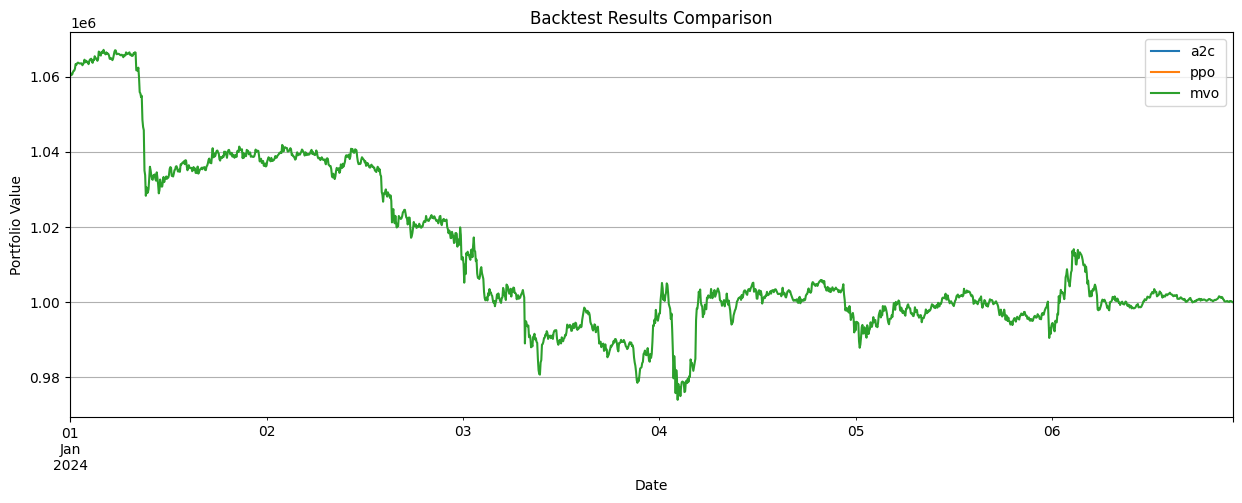


성능 지표 비교

A2C:
  최종 자산: 1,000,000
  총 수익률: 0.00%
  최대 자산: 1,000,000
  최대 낙폭: 0.00%

PPO:
  최종 자산: 1,000,000
  총 수익률: 0.00%
  최대 자산: 1,000,000
  최대 낙폭: 0.00%

MVO:
  최종 자산: 1,000,000
  총 수익률: 0.00%
  최대 자산: 1,067,215
  최대 낙폭: 8.74%

성능 순위 (최종 수익률 기준)
1. A2C: 0.00% (최종: 1,000,000)
2. PPO: 0.00% (최종: 1,000,000)
3. MVO: 0.00% (최종: 1,000,000)


In [ ]:
plt.rcParams["figure.figsize"] = (15,5)
plt.figure()
result.plot()
plt.title("Backtest Results Comparison")
plt.ylabel("Portfolio Value")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# 성능 지표 계산 및 비교
print("\n" + "="*60)
print("성능 지표 비교")
print("="*60)

initial_value = 1_000_000

for col in result.columns:
    if result[col].notna().sum() > 0:
        final_value = result[col].dropna().iloc[-1]
        total_return = (final_value - initial_value) / initial_value * 100
        max_value = result[col].dropna().max()
        max_drawdown = (max_value - result[col].dropna().min()) / max_value * 100
        
        print(f"\n{col.upper()}:")
        print(f"  최종 자산: {final_value:,.0f}")
        print(f"  총 수익률: {total_return:.2f}%")
        print(f"  최대 자산: {max_value:,.0f}")
        print(f"  최대 낙폭: {max_drawdown:.2f}%")

print("\n" + "="*60)
print("성능 순위 (최종 수익률 기준)")
print("="*60)

performance_ranking = []
for col in result.columns:
    if result[col].notna().sum() > 0:
        final_value = result[col].dropna().iloc[-1]
        total_return = (final_value - initial_value) / initial_value * 100
        performance_ranking.append((col, total_return, final_value))

performance_ranking.sort(key=lambda x: x[1], reverse=True)

for i, (model, return_pct, final_val) in enumerate(performance_ranking, 1):
    print(f"{i}. {model.upper()}: {return_pct:.2f}% (최종: {final_val:,.0f})")